# XGBoost Model

In [ ]:
from xgboost import XGBClassifier
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV

### Load Dataset

In [ ]:
X_train = pd.read_csv("telco-data/X_train.csv")
X_test = pd.read_csv("telco-data/X_test.csv")
y_train = pd.read_csv("telco-data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("telco-data/y_test.csv").squeeze("columns")


### Converting Labels

In [ ]:
y_train = y_train.map({"No": 0, "Yes": 1})
y_test = y_test.map({"No": 0, "Yes": 1})


### Training model

In [ ]:
model = XGBClassifier(
    objective='binary:logistic',
    random_state=47,
    early_stopping_rounds=10,
    eval_metric='aucpr',
)

model.fit(
    X_train,
    y_train,
    verbose=True,
    eval_set=[(X_test, y_test)]
)


[0]	validation_0-aucpr:0.61001
[1]	validation_0-aucpr:0.61395
[2]	validation_0-aucpr:0.61915
[3]	validation_0-aucpr:0.61617
[4]	validation_0-aucpr:0.61317
[5]	validation_0-aucpr:0.61923
[6]	validation_0-aucpr:0.61509
[7]	validation_0-aucpr:0.62158
[8]	validation_0-aucpr:0.62457
[9]	validation_0-aucpr:0.62490
[10]	validation_0-aucpr:0.62605
[11]	validation_0-aucpr:0.62679
[12]	validation_0-aucpr:0.62649
[13]	validation_0-aucpr:0.62701
[14]	validation_0-aucpr:0.62640
[15]	validation_0-aucpr:0.62673
[16]	validation_0-aucpr:0.62639
[17]	validation_0-aucpr:0.62854
[18]	validation_0-aucpr:0.62862
[19]	validation_0-aucpr:0.62642
[20]	validation_0-aucpr:0.62586
[21]	validation_0-aucpr:0.62547
[22]	validation_0-aucpr:0.62536
[23]	validation_0-aucpr:0.62475
[24]	validation_0-aucpr:0.62843
[25]	validation_0-aucpr:0.62808
[26]	validation_0-aucpr:0.62719
[27]	validation_0-aucpr:0.62875
[28]	validation_0-aucpr:0.62893
[29]	validation_0-aucpr:0.62639
[30]	validation_0-aucpr:0.62630
[31]	validation_0-

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Confusion Matrix

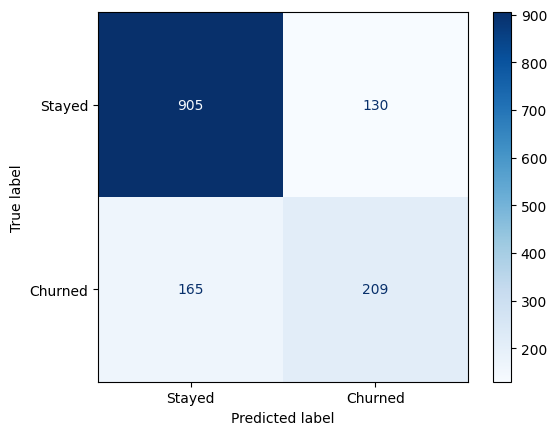

In [ ]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot(cmap="Blues", values_format="d")

The model shows a clear class imbalance effect. Out of 374 customers who actually churned, only 209 were correctly identified (recall ≈ 55.9%), while 165 churners were missed entirely and predicted as "Stayed." In contrast, the model performs well on the majority class, correctly identifying 905 of 1,035 non-churners.

Overall accuracy sits at ~79%, but this is misleading given the imbalance — it's driven largely by the model's strength on the majority class rather than balanced performance across both. Precision on churn predictions is ~61.7% (209 of 339 flagged as "Churned" were correct), meaning the model is more conservative than accurate when predicting churn.

### Optimizing Parameters

In [ ]:
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15],
    'gamma': [0, 0.25, 0.5],
    'reg_lambda': [1.0, 10.0, 20.0],
    'scale_pos_weight': [3, 5, 7]
}

To speed up cross validiation and to further prevent overfitting, we are only using a random subset of the data (90%) and are only using a random subset of the features (columns) (50%) per tree.

In [ ]:
estimator = XGBClassifier(
    objective='binary:logistic',
    seed=47,
    subsample=0.9,
    colsample_bytree=0.5,
    eval_metric='aucpr',
    early_stopping_rounds=10
)

optimal_params = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring='average_precision',
    verbose=0,
    n_jobs=10,
    cv=3
)

optimal_params.fit(X_train,
                   y_train,
                   eval_set=[ (X_test, y_test) ],
                   verbose=False)

print(optimal_params.best_params_)

{'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 4, 'reg_lambda': 10.0, 'scale_pos_weight': 3}


### Final Model

[0]	validation_0-aucpr:0.55630
[1]	validation_0-aucpr:0.56076
[2]	validation_0-aucpr:0.56488
[3]	validation_0-aucpr:0.56607
[4]	validation_0-aucpr:0.57236
[5]	validation_0-aucpr:0.57210
[6]	validation_0-aucpr:0.57272
[7]	validation_0-aucpr:0.59887
[8]	validation_0-aucpr:0.59799
[9]	validation_0-aucpr:0.60220
[10]	validation_0-aucpr:0.60120
[11]	validation_0-aucpr:0.60418
[12]	validation_0-aucpr:0.60680
[13]	validation_0-aucpr:0.60939
[14]	validation_0-aucpr:0.61042
[15]	validation_0-aucpr:0.61011
[16]	validation_0-aucpr:0.61088
[17]	validation_0-aucpr:0.61030
[18]	validation_0-aucpr:0.60960
[19]	validation_0-aucpr:0.61192
[20]	validation_0-aucpr:0.61152
[21]	validation_0-aucpr:0.61445
[22]	validation_0-aucpr:0.61484
[23]	validation_0-aucpr:0.61513
[24]	validation_0-aucpr:0.61548
[25]	validation_0-aucpr:0.61775
[26]	validation_0-aucpr:0.61599
[27]	validation_0-aucpr:0.61580
[28]	validation_0-aucpr:0.61635
[29]	validation_0-aucpr:0.61669
[30]	validation_0-aucpr:0.61731
[31]	validation_0-

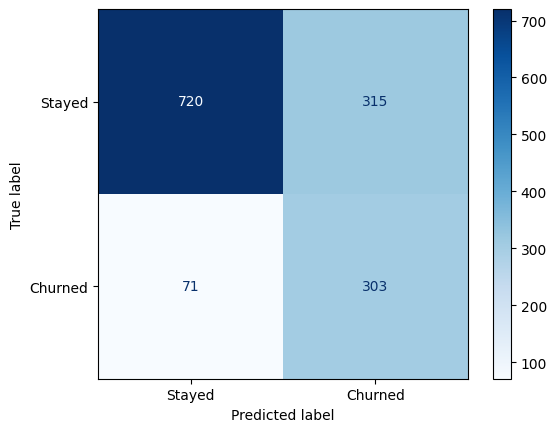

In [ ]:
model = XGBClassifier(
    objective='binary:logistic',
    random_state=47,
    early_stopping_rounds=10,
    eval_metric='aucpr',
    learning_rate = 0.1,
    max_depth=4,
    reg_lambda=10.0,
    gamma=0.5,
    scale_pos_weight=3
)

model.fit(
    X_train,
    y_train,
    verbose=True,
    eval_set=[(X_test, y_test)]
)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
).plot(cmap="Blues", values_format="d")